# CNN model

Simple CNN model for the everyday objects category using Google Quick, Draw!
1. Loads categories from `../../categories/objects.txt`
2. Downloads Quick, Draw! sketches
3. Converts each drawing into a 28x28 image
4. Trains a CNN using PyTorch
5. Saves accuracy/loss graphs and the trained model

In [3]:
from pathlib import Path
import random

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from quickdraw import QuickDrawDataGroup

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [4]:
SEED = 42
SAMPLES_PER_CATEGORY = 200
IMAGE_SIZE = 28
BATCH_SIZE = 32
EPOCHS = 8
LEARNING_RATE = 0.001

CATEGORY_FILE = Path("../../categories/objects.txt")
RESULTS_DIR = Path("objects_cnn_results")
RESULTS_DIR.mkdir(exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("Setup complete")

Setup complete


## Load category names

The category file contains the everyday object labels that this CNN will learn to classify.

In [9]:
with open(CATEGORY_FILE, "r") as f:
    text = f.read()

categories = [
    category.strip()
    for category in text.replace("\n", ",").split(",")
    if category.strip()
]

label_map = {category: index for index, category in enumerate(categories)}
reverse_label_map = {index: category for category, index in label_map.items()}

print("Number of categories:", len(categories))
print(categories)

Number of categories: 23
['backpack', 'bed', 'book', 'calendar', 'cell phone', 'chair', 'clock', 'computer', 'couch', 'cup', 'door', 'dresser', 'fan', 'key', 'knife', 'laptop', 'microwave', 'shoe', 'spoon', 'table', 'television', 'toilet', 'toothbrush']


## Convert drawings into image arrays

Quick, Draw! sketches are converted into 28x28 grayscale images.

The image is inverted so the drawing strokes are bright and the background is dark.

In [10]:
def drawing_to_array(drawing, image_size=28):
    image = drawing.image
    
    # Convert to grayscale
    image = image.convert("L")
    
    # Resize to 28x28
    image = image.resize((image_size, image_size), Image.Resampling.LANCZOS)
    
    # Convert image to numpy array
    array = np.array(image).astype(np.float32)
    
    # Invert so black drawing lines become bright values
    array = 255.0 - array
    
    # Normalize from 0-255 to 0-1
    array = array / 255.0
    
    return array

## Build dataset

This cell loads drawings for each object category.

For testing, keep `SAMPLES_PER_CATEGORY` small. Later, increase it to improve accuracy.

In [11]:
X = []
y = []

for category in categories:
    print(f"Loading {category}...")
    
    group = QuickDrawDataGroup(
        category,
        max_drawings=SAMPLES_PER_CATEGORY,
        print_messages=False
    )
    
    count = 0
    
    for drawing in group.drawings:
        array = drawing_to_array(drawing, IMAGE_SIZE)
        
        X.append(array)
        y.append(label_map[category])
        
        count += 1
        
        if count >= SAMPLES_PER_CATEGORY:
            break
    
    print(f"Loaded {count} drawings for {category}")

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int64)

print("X shape:", X.shape)
print("y shape:", y.shape)

Loading backpack...
Loaded 200 drawings for backpack
Loading bed...
Loaded 200 drawings for bed
Loading book...
Loaded 200 drawings for book
Loading calendar...
Loaded 200 drawings for calendar
Loading cell phone...
Loaded 200 drawings for cell phone
Loading chair...
Loaded 200 drawings for chair
Loading clock...
Loaded 200 drawings for clock
Loading computer...
Loaded 200 drawings for computer
Loading couch...
Loaded 200 drawings for couch
Loading cup...
Loaded 200 drawings for cup
Loading door...
Loaded 200 drawings for door
Loading dresser...
Loaded 200 drawings for dresser
Loading fan...
Loaded 200 drawings for fan
Loading key...
Loaded 200 drawings for key
Loading knife...
Loaded 200 drawings for knife
Loading laptop...
Loaded 200 drawings for laptop
Loading microwave...
Loaded 200 drawings for microwave
Loading shoe...
Loaded 200 drawings for shoe
Loading spoon...
Loaded 200 drawings for spoon
Loading table...
Loaded 200 drawings for table
Loading television...
Loaded 200 drawing

## Preview drawings

Before training, we check a few examples to make sure the images loaded correctly.

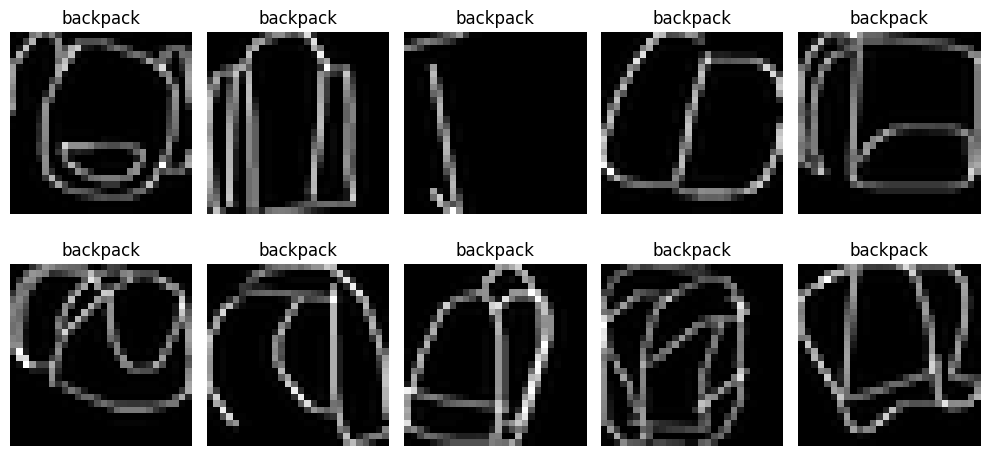

In [12]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X[i], cmap="gray")
    plt.title(reverse_label_map[y[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

## Prepare CNN data

PyTorch CNNs expect image data in this format:

`number of images, color channels, height, width`

Since these are grayscale images, the number of channels is 1.

In [13]:
# Add channel dimension: (samples, 1, 28, 28)
X_cnn = X[:, np.newaxis, :, :]

X_train, X_test, y_train, y_test = train_test_split(
    X_cnn,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Training data:", X_train_tensor.shape)
print("Testing data:", X_test_tensor.shape)

Training data: torch.Size([3680, 1, 28, 28])
Testing data: torch.Size([920, 1, 28, 28])


## Define the CNN model

This simple CNN has:

- 2 convolution layers
- 2 max pooling layers
- 1 dropout layer
- 1 final classification layer

In [14]:
class SimpleObjectCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        
        self.layers = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Flatten(),
            
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        return self.layers(x)

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SimpleObjectCNN(num_classes=len(categories)).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print("Using device:", device)
print(model)

Using device: cpu
SimpleObjectCNN(
  (layers): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=1568, out_features=128, bias=True)
    (8): ReLU()
    (9): Dropout(p=0.3, inplace=False)
    (10): Linear(in_features=128, out_features=23, bias=True)
  )
)


## Train the CNN

The model trains for multiple epochs.

After each epoch, the notebook prints:

- training loss
- test accuracy

In [16]:
train_losses = []
test_accuracies = []

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    average_loss = total_loss / len(train_loader)
    
    # Evaluate after each epoch
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            predictions = torch.argmax(outputs, dim=1)
            
            correct += (predictions == labels).sum().item()
            total += labels.size(0)
    
    test_accuracy = correct / total
    
    train_losses.append(average_loss)
    test_accuracies.append(test_accuracy)
    
    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Loss: {average_loss:.4f} | "
        f"Test Accuracy: {test_accuracy:.4f}"
    )

Epoch 1/8 | Loss: 3.0068 | Test Accuracy: 0.2652
Epoch 2/8 | Loss: 2.3375 | Test Accuracy: 0.3967
Epoch 3/8 | Loss: 2.0653 | Test Accuracy: 0.4728
Epoch 4/8 | Loss: 1.9032 | Test Accuracy: 0.5054
Epoch 5/8 | Loss: 1.7669 | Test Accuracy: 0.5315
Epoch 6/8 | Loss: 1.6335 | Test Accuracy: 0.5576
Epoch 7/8 | Loss: 1.5293 | Test Accuracy: 0.5913
Epoch 8/8 | Loss: 1.4410 | Test Accuracy: 0.5935


## Final accuracy

This calculates the final CNN accuracy on the test set.

In [17]:
model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        
        outputs = model(images)
        predictions = torch.argmax(outputs, dim=1)
        
        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.numpy())

cnn_accuracy = accuracy_score(all_labels, all_predictions)

print(f"Final CNN accuracy: {cnn_accuracy:.4f}")

Final CNN accuracy: 0.5935


## Plot training loss

This graph shows whether the model's training loss decreased over time.

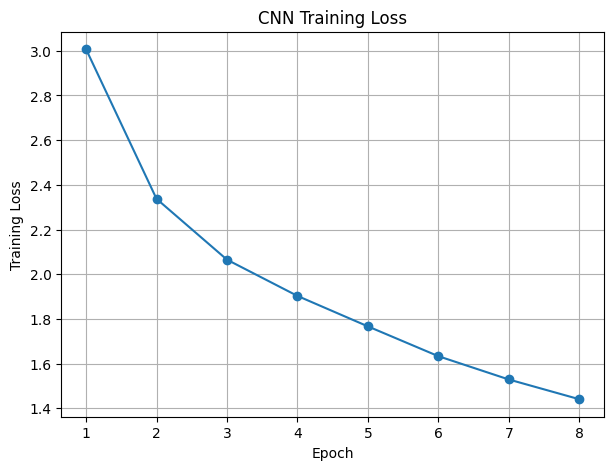

In [18]:
plt.figure(figsize=(7, 5))
plt.plot(range(1, EPOCHS + 1), train_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("CNN Training Loss")
plt.grid(True)
plt.savefig(RESULTS_DIR / "cnn_training_loss.png")
plt.show()

## Plot test accuracy

This graph shows how the CNN accuracy changed after each epoch.

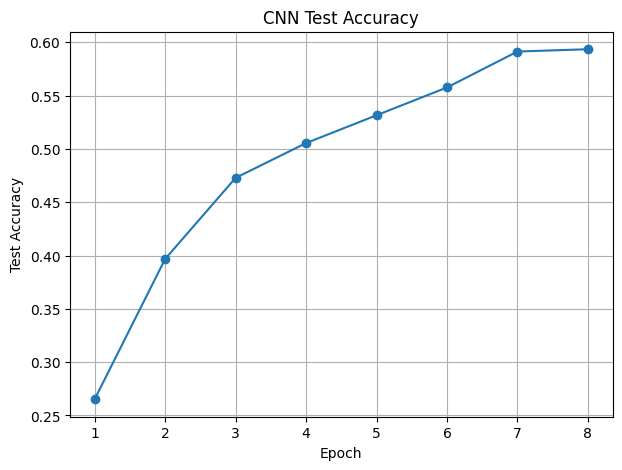

In [19]:
plt.figure(figsize=(7, 5))
plt.plot(range(1, EPOCHS + 1), test_accuracies, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title("CNN Test Accuracy")
plt.grid(True)
plt.savefig(RESULTS_DIR / "cnn_test_accuracy.png")
plt.show()

## Confusion matrix

The confusion matrix shows which categories the CNN mixes up most often.

<Figure size 1200x1200 with 0 Axes>

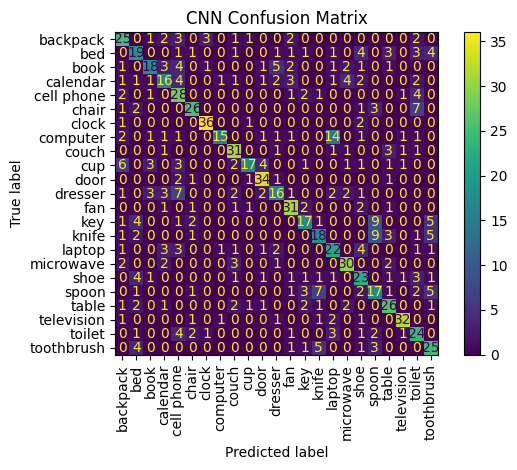

In [21]:
cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(12, 12))

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=categories
)

display.plot(xticks_rotation=90, values_format="d")
plt.title("CNN Confusion Matrix")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "cnn_confusion_matrix.png")
plt.show()

## Example predictions

This section shows a few test drawings with the model's predicted label.

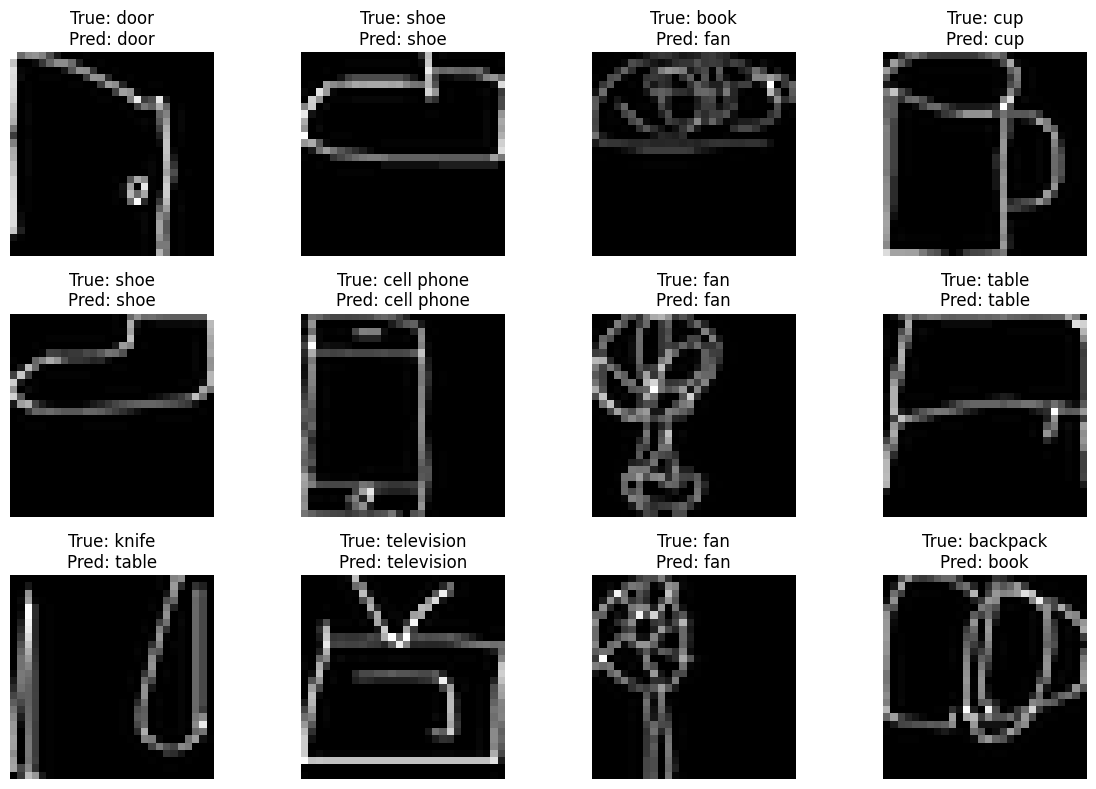

In [22]:
model.eval()

plt.figure(figsize=(12, 8))

for i in range(12):
    image = X_test_tensor[i].unsqueeze(0).to(device)
    true_label = y_test_tensor[i].item()
    
    with torch.no_grad():
        output = model(image)
        predicted_label = torch.argmax(output, dim=1).item()
    
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_test_tensor[i].squeeze(), cmap="gray")
    plt.title(
        f"True: {reverse_label_map[true_label]}\n"
        f"Pred: {reverse_label_map[predicted_label]}"
    )
    plt.axis("off")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "cnn_example_predictions.png")
plt.show()

## Save model

This saves the trained CNN model and the label information needed to use it later.

In [23]:
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "categories": categories,
        "label_map": label_map,
        "image_size": IMAGE_SIZE,
        "samples_per_category": SAMPLES_PER_CATEGORY,
        "accuracy": cnn_accuracy,
    },
    RESULTS_DIR / "objects_cnn_model.pt"
)

print("Saved model to:", RESULTS_DIR / "objects_cnn_model.pt")

Saved model to: objects_cnn_results/objects_cnn_model.pt


In [24]:
for file in RESULTS_DIR.iterdir():
    print(file)

objects_cnn_results/objects_cnn_model.pt
objects_cnn_results/cnn_training_loss.png
objects_cnn_results/cnn_confusion_matrix.png
objects_cnn_results/cnn_example_predictions.png
objects_cnn_results/cnn_test_accuracy.png
